# TP Industrie 4.0 — Apprentissage supervisé / Régression

## Projet : InnoMoov — Prédiction intelligente du trafic urbain

Dans le cadre du projet InnoMoov, entreprise spécialisée dans la mobilité urbaine intelligente, l’objectif de ce TP est de mettre en place un modèle d’apprentissage supervisé capable de prédire le volume de trafic routier.

Cette problématique industrielle s’inscrit dans une logique Industrie 4.0 : exploitation des données, aide à la décision, optimisation des flux, supervision intelligente et amélioration de la performance opérationnelle.

Le cas étudié consiste à prédire une variable numérique : le volume de trafic.  
Il s’agit donc d’un problème de régression supervisée.

## Objectifs du notebook

1. Identifier un besoin industriel concret.
2. Utiliser un dataset adapté au problème.
3. Justifier le choix de l’algorithme avec la carte d’orientation Scikit-Learn.
4. Entraîner un modèle de régression en quelques lignes.
5. Évaluer ses performances.
6. Visualiser les résultats avec des graphiques lisibles et professionnels.
7. Utiliser le modèle pour produire des prédictions exploitables dans le processus industriel InnoMoov.

---

## 1. Besoin industriel identifié

InnoMoov développe des solutions de mobilité intelligente pour les villes et les opérateurs de flotte électrique.

Dans ce contexte, un problème industriel important est la **prévision du trafic urbain**. Une mauvaise anticipation du trafic peut entraîner :

- des retards dans les déplacements ;
- une mauvaise répartition des véhicules ;
- une hausse de la consommation énergétique ;
- une augmentation des émissions de CO₂ ;
- une dégradation de l’expérience utilisateur ;
- une surcharge de certaines zones urbaines.

L’objectif industriel est donc de prédire le **volume de trafic** à partir de variables explicatives comme l’heure, la météo, le jour de la semaine, les jours fériés ou encore les conditions climatiques.

Cette prédiction permettra à InnoMoov de passer d’une gestion réactive à une gestion prédictive de la mobilité urbaine.

---

In [ ]:
# ==============================
# Import des librairies
# ==============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

# Style graphique personnalisé
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.facecolor"] = "#F7F7F7"
plt.rcParams["figure.facecolor"] = "#FFFFFF"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["font.weight"] = "regular"

print("Librairies importées.")

Librairies importées avec succès.


---

## 2. Dataset utilisé

Ce dataset contient des observations liées au trafic routier, avec des variables telles que :

- la date et l’heure ;
- la température ;
- la pluie ;
- la neige ;
- la couverture nuageuse ;
- les conditions météo ;
- les jours fériés ;
- le volume de trafic.

La variable cible à prédire est :

**`traffic_volume`** : volume de trafic observé sur une période donnée.

In [20]:
# ==============================
# Chargement du dataset
# ==============================

df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")

print("Dataset chargé avec succès.")
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

df.head()

Dataset chargé avec succès.
Nombre de lignes : 48204
Nombre de colonnes : 9


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [21]:
# ==============================
# Inspection valeurs manquantes
# ==============================

display(df.info())

print("\nValeurs manquantes par colonne :")
display(df.isna().sum())

print("\nStatistiques descriptives :")
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 3.3 MB


None


Valeurs manquantes par colonne :


holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64


Statistiques descriptives :


,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


In [22]:
# ==============================
# Nettoyage et feature engineering
# ==============================

df_clean = df.copy()

# Gestion des jours fériés
df_clean["holiday"] = df_clean["holiday"].fillna("None")

# Conversion de la date
df_clean["date_time"] = pd.to_datetime(df_clean["date_time"])

# Création de variables temporelles utiles
df_clean["hour"] = df_clean["date_time"].dt.hour
df_clean["dayofweek"] = df_clean["date_time"].dt.dayofweek
df_clean["month"] = df_clean["date_time"].dt.month
df_clean["year"] = df_clean["date_time"].dt.year
df_clean["is_weekend"] = df_clean["dayofweek"].isin([5, 6]).astype(int)

# Température en Celsius
df_clean["temp_celsius"] = df_clean["temp"] - 273.15

df_clean.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,dayofweek,month,year,is_weekend,temp_celsius
0,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,1,10,2012,0,15.13
1,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,1,10,2012,0,16.21
2,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,1,10,2012,0,16.43
3,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,1,10,2012,0,16.98
4,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,1,10,2012,0,17.99


---

## 3. Choix de l’algorithme avec la carte Scikit-Learn

La carte d’orientation Scikit-Learn guide le choix du modèle selon la nature du problème.

Dans notre cas :

- les données sont supervisées ;
- la variable cible `traffic_volume` est numérique ;
- il s’agit donc d’un problème de régression ;
- le dataset contient moins de 100 000 observations ;
- les relations entre trafic, météo et temporalité sont probablement non linéaires.

Nous retenons donc un modèle de type **Random Forest Regressor**.

Ce modèle est adapté car il gère bien les relations complexes, les interactions entre variables et les effets non linéaires.

In [23]:
# ==============================
# Sélection des variables
# ==============================

target = "traffic_volume"

features = [
    "holiday",
    "temp_celsius",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "weather_main",
    "hour",
    "dayofweek",
    "month",
    "is_weekend"
]

X = df_clean[features]
y = df_clean[target]

print("Variables explicatives :", X.columns.tolist())
print("Variable cible :", target)
print("Shape X :", X.shape)
print("Shape y :", y.shape)

Variables explicatives : ['holiday', 'temp_celsius', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'hour', 'dayofweek', 'month', 'is_weekend']
Variable cible : traffic_volume
Shape X : (48204, 10)
Shape y : (48204,)


In [24]:
# ==============================
# Séparation apprentissage / test
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Taille X_train :", X_train.shape)
print("Taille X_test :", X_test.shape)
print("Taille y_train :", y_train.shape)
print("Taille y_test :", y_test.shape)

Taille X_train : (38563, 10)
Taille X_test : (9641, 10)
Taille y_train : (38563,)
Taille y_test : (9641,)


In [25]:
# ==============================
# 7. Prétraitement des variables
# ==============================

numeric_features = [
    "temp_celsius",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "hour",
    "dayofweek",
    "month",
    "is_weekend"
]

categorical_features = [
    "holiday",
    "weather_main"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Prétraitement défini.")

Prétraitement défini.


In [26]:
# Le modèle et son entraînement

model = Pipeline(steps=[("preprocessor", preprocessor), ("regressor", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
score = model.score(X_test, y_test)

print(f"Score R² du modèle : {score:.4f}")

Score R² du modèle : 0.9478


In [27]:
# Évaluation du modèle

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.2f} véhicules")
print(f"RMSE : {rmse:.2f} véhicules")

R²   : 0.9478
MAE  : 250.78 véhicules
RMSE : 454.14 véhicules


## 4. Résultats du modèle

Le modèle **Random Forest Regressor** obtient les performances suivantes :

- **R² = 0,9478**
- **MAE = 250,78 véhicules**
- **RMSE = 454,14 véhicules**

Le score R² montre que le modèle explique environ **94,8 % de la variation du volume de trafic** sur les données de test.  
C’est une performance très satisfaisante pour un cas industriel de prédiction du trafic.

L’erreur absolue moyenne indique que le modèle se trompe en moyenne d’environ **251 véhicules** par observation.  
Dans un contexte de mobilité urbaine, cette erreur reste acceptable pour orienter des décisions opérationnelles comme l’ajustement des itinéraires, la régulation des flux ou l’anticipation des zones de congestion.

Le RMSE étant plus élevé que le MAE, cela indique que certaines erreurs importantes subsistent probablement lors de situations atypiques : météo extrême, jour férié, pic de trafic ou événement particulier.

Globalement, le modèle est suffisamment performant pour être utilisé comme outil d’aide à la décision dans le processus industriel InnoMoov.

---

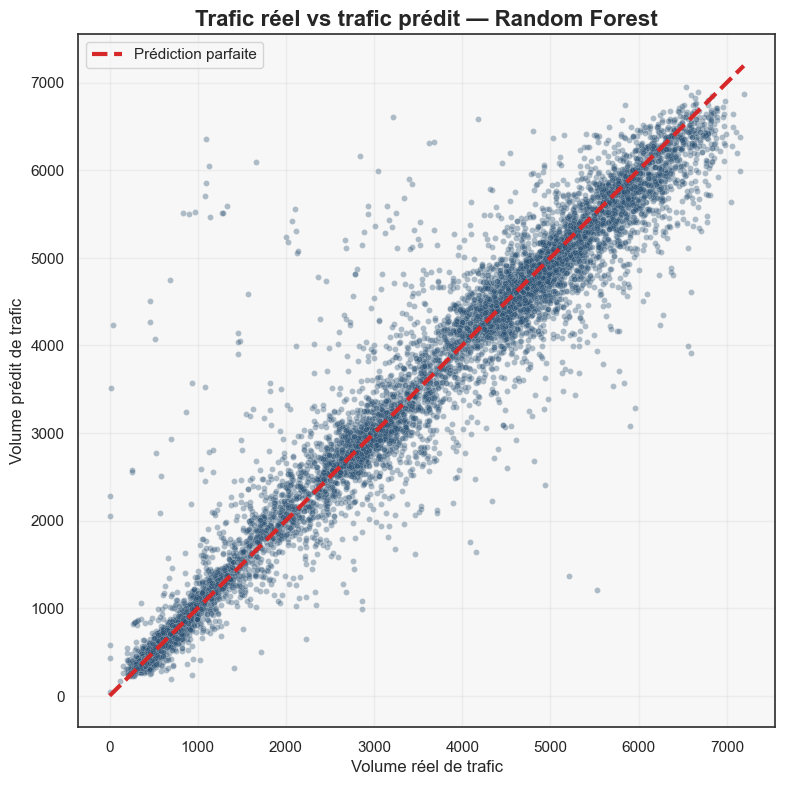

In [28]:
# Graphique Réel vs Prédit

plt.figure(figsize=(9, 9))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.35,
    s=18,
    color="#254D70",
    edgecolor="#EFEFEF",
    linewidth=0.25
)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="#D62828",
    linewidth=3,
    linestyle="--",
    label="Prédiction parfaite"
)

plt.title("Trafic réel vs trafic prédit — Random Forest", fontweight="bold")
plt.xlabel("Volume réel de trafic")
plt.ylabel("Volume prédit de trafic")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

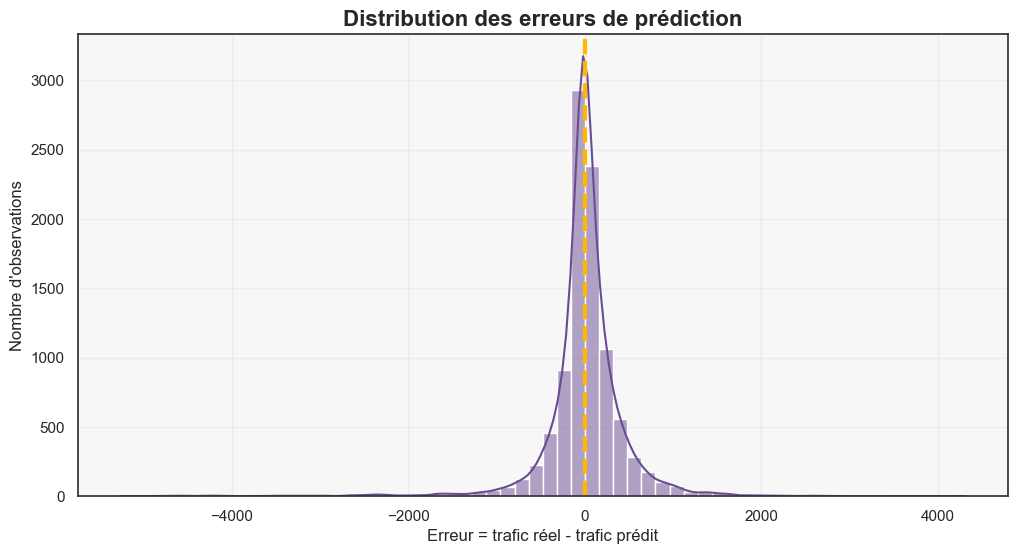

In [29]:
# 11. Distribution des erreurs

errors = y_test - y_pred

plt.figure(figsize=(12, 6))

sns.histplot(
    errors,
    bins=60,
    kde=True,
    color="#6A4C93",
    edgecolor="#FFFFFF"
)

plt.axvline(0, color="#FFB703", linewidth=3, linestyle="--")

plt.title("Distribution des erreurs de prédiction", fontweight="bold")
plt.xlabel("Erreur = trafic réel - trafic prédit")
plt.ylabel("Nombre d'observations")
plt.grid(alpha=0.25)
plt.show()

## 6. Analyse des erreurs

La distribution des erreurs est centrée autour de zéro, ce qui indique que le modèle ne présente pas de biais fort de sur-prédiction ou de sous-prédiction.

La majorité des erreurs reste concentrée dans une zone réduite, ce qui confirme la stabilité du modèle.  
Les valeurs extrêmes correspondent probablement à des situations particulières : trafic inhabituel, météo exceptionnelle, événement local ou rupture de comportement.

Cette analyse montre que le modèle est fiable pour une exploitation opérationnelle, tout en nécessitant une vigilance sur les cas atypiques.

---

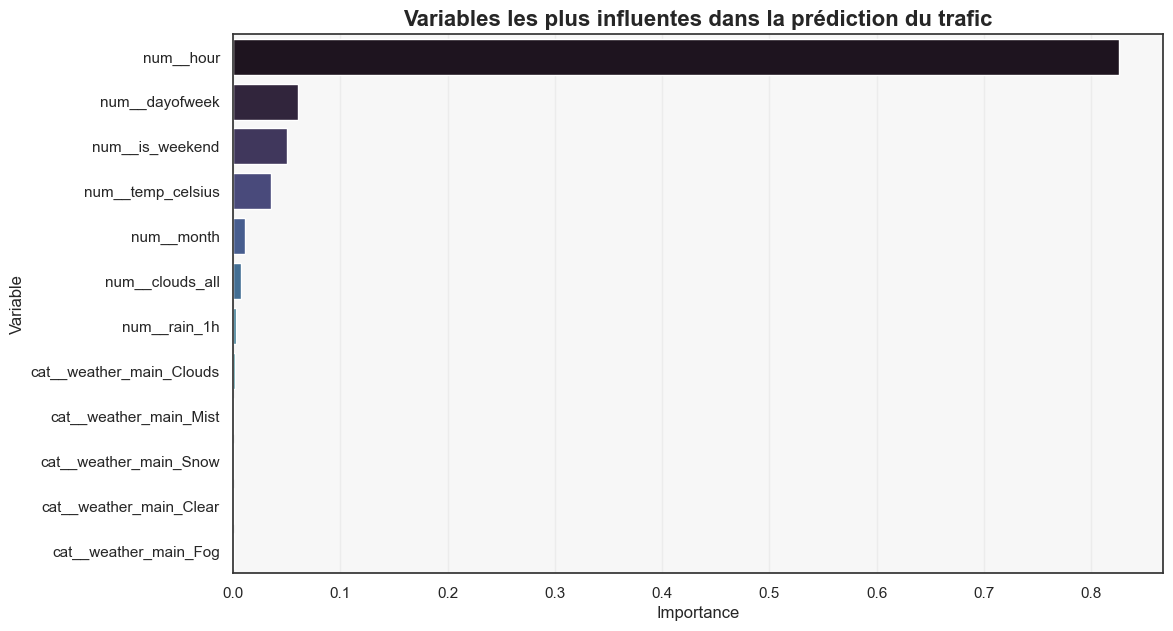

,feature,importance
4,num__hour,0.825726
5,num__dayofweek,0.060371
7,num__is_weekend,0.050680
0,num__temp_celsius,0.035180
6,num__month,0.010869
3,num__clouds_all,0.007068
1,num__rain_1h,0.002795
21,cat__weather_main_Clouds,0.001957
25,cat__weather_main_Mist,0.000956
28,cat__weather_main_Snow,0.000916


In [30]:
# Importance des variables

rf_model = model.named_steps["regressor"]
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

importances = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

top_importances = importances.head(12)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_importances,
    x="importance",
    y="feature",
    palette="mako"
)

plt.title("Variables les plus influentes dans la prédiction du trafic", fontweight="bold")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.grid(axis="x", alpha=0.25)
plt.show()

top_importances

## 7. Importance des variables

La variable la plus déterminante est **l’heure de la journée**, avec une importance très élevée.

Cela confirme que le trafic dépend principalement des rythmes urbains : heures de pointe, trajets domicile-travail, baisse du trafic la nuit.

Le **jour de la semaine** et la variable **week-end** arrivent ensuite.  
Ils montrent que les comportements de déplacement sont différents entre jours ouvrés et week-end.

La météo influence aussi le modèle, mais de façon plus secondaire.  
Dans ce dataset, la temporalité explique donc davantage le trafic que les conditions climatiques.

Pour InnoMoov, cette lecture est importante : l’optimisation de flotte doit prioritairement intégrer les créneaux horaires et les jours critiques.

---

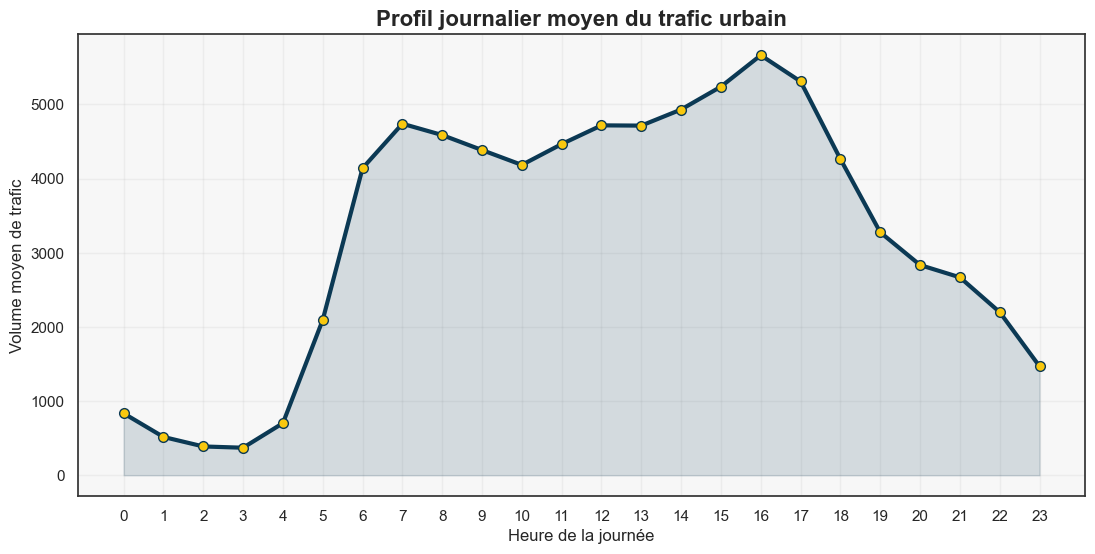

In [31]:
# Trafic moyen par heure

hourly_traffic = df_clean.groupby("hour")["traffic_volume"].mean().reset_index()

plt.figure(figsize=(13, 6))

plt.plot(
    hourly_traffic["hour"],
    hourly_traffic["traffic_volume"],
    color="#0B3954",
    linewidth=3,
    marker="o",
    markersize=7,
    markerfacecolor="#F9C80E",
    markeredgecolor="#0B3954"
)

plt.fill_between(
    hourly_traffic["hour"],
    hourly_traffic["traffic_volume"],
    color="#0B3954",
    alpha=0.15
)

plt.title("Profil journalier moyen du trafic urbain", fontweight="bold")
plt.xlabel("Heure de la journée")
plt.ylabel("Volume moyen de trafic")
plt.xticks(range(0, 24))
plt.grid(alpha=0.25)
plt.show()

## 8. Profil journalier du trafic

Le graphique montre que le trafic varie fortement selon l’heure.

Les volumes les plus élevés correspondent aux périodes de déplacement intensif, notamment les heures de pointe.  
À l’inverse, le trafic diminue fortement pendant les heures creuses et la nuit.

Cette observation confirme l’importance de la variable `hour` dans le modèle.

---

## 9. Utilisation du modèle pour le process industriel

Le modèle est utilisé pour prédire le volume de trafic dans plusieurs situations représentatives : heure de pointe du matin, heure de pointe du soir sous la pluie, et circulation de week-end.

Ces prédictions permettent à InnoMoov de mieux piloter ses solutions de mobilité intelligente.

L’intérêt industriel est concret :

- anticiper les zones de congestion ;
- ajuster dynamiquement les itinéraires des flottes électriques ;
- optimiser la disponibilité des véhicules ;
- réduire les retards ;
- limiter la consommation énergétique ;
- diminuer les émissions de CO₂ ;
- améliorer la qualité de service pour les villes et opérateurs partenaires.

Le modèle devient donc un outil d’aide à la décision pour passer d’une gestion réactive du trafic à une gestion prédictive.

In [32]:
# Prédictions sur scénarios industriels

scenarios = pd.DataFrame([
    {
        "holiday": "None",
        "temp_celsius": 18,
        "rain_1h": 0,
        "snow_1h": 0,
        "clouds_all": 20,
        "weather_main": "Clear",
        "hour": 8,
        "dayofweek": 0,
        "month": 5,
        "is_weekend": 0
    },
    {
        "holiday": "None",
        "temp_celsius": 12,
        "rain_1h": 3,
        "snow_1h": 0,
        "clouds_all": 90,
        "weather_main": "Rain",
        "hour": 18,
        "dayofweek": 4,
        "month": 11,
        "is_weekend": 0
    },
    {
        "holiday": "None",
        "temp_celsius": 22,
        "rain_1h": 0,
        "snow_1h": 0,
        "clouds_all": 10,
        "weather_main": "Clear",
        "hour": 14,
        "dayofweek": 6,
        "month": 7,
        "is_weekend": 1
    }
])

scenarios["traffic_volume_predicted"] = model.predict(scenarios).round(0).astype(int)

scenarios

,holiday,temp_celsius,rain_1h,snow_1h,clouds_all,weather_main,hour,dayofweek,month,is_weekend,traffic_volume_predicted
0,None,18,0,0,20,Clear,8,0,5,0,5695
1,None,12,3,0,90,Rain,18,4,11,0,4531
2,None,22,0,0,10,Clear,14,6,7,1,4378


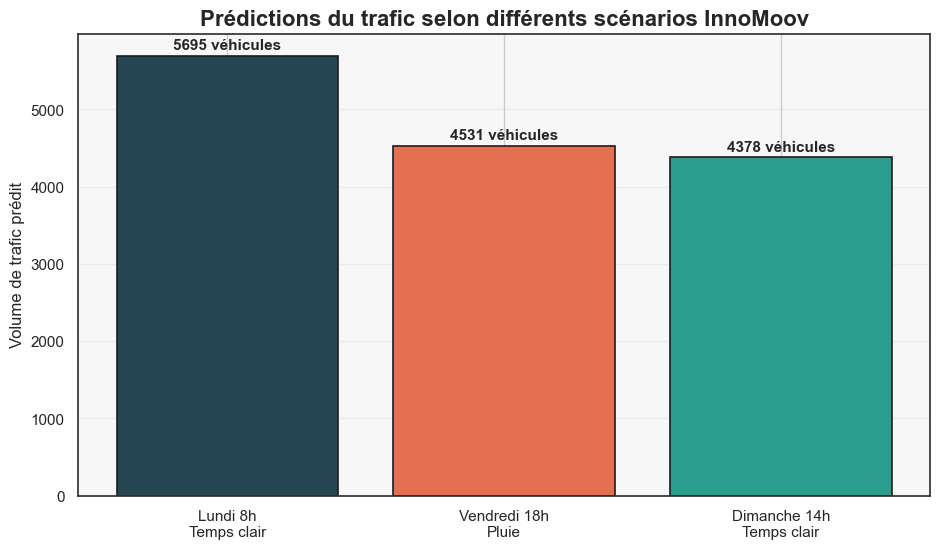

In [33]:
# Visualisation des scénarios prédits

scenario_labels = [
    "Lundi 8h\nTemps clair",
    "Vendredi 18h\nPluie",
    "Dimanche 14h\nTemps clair"
]

plt.figure(figsize=(11, 6))

bars = plt.bar(
    scenario_labels,
    scenarios["traffic_volume_predicted"],
    color=["#264653", "#E76F51", "#2A9D8F"],
    edgecolor="#1D1D1D",
    linewidth=1.2
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 80,
        f"{int(height)} véhicules",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title("Prédictions du trafic selon différents scénarios InnoMoov", fontweight="bold")
plt.ylabel("Volume de trafic prédit")
plt.grid(axis="y", alpha=0.25)
plt.show()

## 10. Conclusion

Ce TP a permis de construire un modèle de régression supervisée appliqué à un besoin industriel concret : la prédiction du trafic urbain pour InnoMoov.

À partir du dataset Metro Interstate Traffic Volume, nous avons entraîné un modèle **Random Forest Regressor** choisi à l’aide de la carte d’orientation Scikit-Learn.

Le modèle obtient un score très satisfaisant avec :

- **R² = 0,9478**
- **MAE = 250,78 véhicules**
- **RMSE = 454,14 véhicules**

Les résultats montrent que l’heure, le jour de la semaine et le week-end sont les facteurs les plus importants dans la prédiction du trafic.

Pour InnoMoov, ce modèle peut être intégré dans une logique Industrie 4.0 afin d’anticiper les embouteillages, optimiser les flottes électriques, améliorer la mobilité urbaine et réduire l’impact environnemental.

La donnée devient ainsi un levier opérationnel pour rendre la mobilité plus intelligente, plus fluide et plus durable.